In [1]:
import numpy as np
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
import pickle
import wntr
import pandas as pd

In [2]:
# Create a water network model
inp_file = 'CTOWN.inp'
wn = wntr.network.WaterNetworkModel(inp_file)

C:\Users\ADMIN\AppData\Roaming\Python\Python39\site-packages\wntr\epanet\io.py:2082: UserWarning: Not all curves were used in "CTOWN.inp"; added with type None, units conversion left to user
  warnings.warn('Not all curves were used in "{}"; added with type None, units conversion left to user'.format(self.wn.name))


['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', '

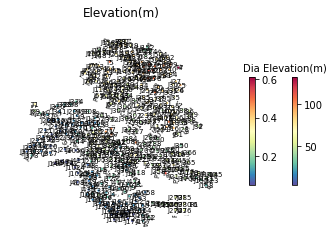

In [3]:
#ax = wntr.graphics.plot_network(wn, node_attribute='elevation',node_colorbar_label='Elevation(m)')
A=wn.node_name_list
print(A)
B=wn.link_name_list
print(B)
ax = wntr.graphics.network.plot_network(wn, node_attribute='elevation', link_attribute='diameter', title='Elevation(m)', node_size=5, node_range=[None, None], node_alpha=1, node_cmap=None, node_labels=True, link_width=1, link_range=[None, None], link_alpha=1, link_cmap=None, link_labels=True, add_colorbar=True, node_colorbar_label='Elevation(m)', link_colorbar_label='Dia', directed=False, ax=None, filename=None)

In [4]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [5]:
coeff = [[],[]]
for i in range(len(A2)):
    junction = wn.get_link(A2[i])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
    pat_i = junction.roughness
    coeff[0].append(A2[i])
    coeff[1].append(pat_i)
    print(f'{A2[i]} have coeff {pat_i}')

P1 have coeff 72.4549266
P10 have coeff 108.0095074
P100 have coeff 76.51422883
P1000 have coeff 76.94614787
P101 have coeff 84.20845169
P1016 have coeff 85.23817366
P102 have coeff 92.94722922
P1022 have coeff 99.58078005
P1023 have coeff 95.68850653
P1024 have coeff 89.62069894
P1025 have coeff 97.77659267
P1026 have coeff 88.45039526
P1027 have coeff 92.0106009
P1028 have coeff 86.99339612
P1029 have coeff 91.33959845
P103 have coeff 79.37099717
P1030 have coeff 104.6083303
P1031 have coeff 84.37414232
P1032 have coeff 98.43095137
P1033 have coeff 84.68939593
P1034 have coeff 97.41854735
P1035 have coeff 97.7581413
P1036 have coeff 74.29791874
P1039 have coeff 92.14229573
P104 have coeff 99.88658284
P1040 have coeff 94.68876721
P1041 have coeff 112.5081558
P1042 have coeff 76.15024112
P1044 have coeff 100.2182444
P1045 have coeff 118.82139
P106 have coeff 63.55113264
P107 have coeff 80.50983232
P108 have coeff 78.72048108
P109 have coeff 76.89340854
P11 have coeff 96.83442437
P110 h

In [6]:
coeff

[['P1',
  'P10',
  'P100',
  'P1000',
  'P101',
  'P1016',
  'P102',
  'P1022',
  'P1023',
  'P1024',
  'P1025',
  'P1026',
  'P1027',
  'P1028',
  'P1029',
  'P103',
  'P1030',
  'P1031',
  'P1032',
  'P1033',
  'P1034',
  'P1035',
  'P1036',
  'P1039',
  'P104',
  'P1040',
  'P1041',
  'P1042',
  'P1044',
  'P1045',
  'P106',
  'P107',
  'P108',
  'P109',
  'P11',
  'P110',
  'P111',
  'P112',
  'P113',
  'P115',
  'P116',
  'P117',
  'P118',
  'P119',
  'P12',
  'P120',
  'P121',
  'P122',
  'P123',
  'P124',
  'P125',
  'P126',
  'P127',
  'P128',
  'P129',
  'P13',
  'P130',
  'P131',
  'P132',
  'P134',
  'P136',
  'P138',
  'P139',
  'P14',
  'P140',
  'P141',
  'P142',
  'P144',
  'P147',
  'P148',
  'P15',
  'P150',
  'P154',
  'P155',
  'P156',
  'P157',
  'P158',
  'P159',
  'P16',
  'P160',
  'P161',
  'P162',
  'P163',
  'P165',
  'P166',
  'P17',
  'P174',
  'P177',
  'P18',
  'P184',
  'P19',
  'P195',
  'P2',
  'P20',
  'P201',
  'P21',
  'P211',
  'P215',
  'P218',
  '

In [7]:
node_n =['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', 'J74', 'J76', 'J77', 'J78', 'J350', 'J351', 'J352', 'J353', 'J354', 'J355', 'J358', 'J359', 'J250', 'J251', 'J252', 'J253', 'J254', 'J257', 'J154', 'J155', 'J82', 'J156', 'J83', 'J84', 'J85', 'J159', 'J86', 'J87', 'J89', 'J360', 'J361', 'J362', 'J363', 'J364', 'J365', 'J366', 'J1208', 'J367', 'J369', 'J160', 'J161', 'J162', 'J163', 'J164', 'J91', 'J165', 'J166', 'J167', 'J94', 'J95', 'J96', 'J97', 'J976', 'J571', 'J572', 'J573', 'J574', 'J575', 'J576', 'J370', 'J371', 'J372', 'J373', 'J374', 'J375', 'J376', 'J377', 'J1219', 'J379', 'J171', 'J172', 'J173', 'J174', 'J175', 'J177', 'J179', 'J580', 'J486', 'J487', 'J488', 'J489', 'J381', 'J1223', 'J382', 'J384', 'J385', 'J180', 'J181', 'J1024', 'J183', 'J1025', 'J186', 'J187', 'J188', 'J189', 'J490', 'J491', 'J492', 'J493', 'J494', 'J495', 'J496', 'J497', 'J498', 'J500', 'J499', 'J501', 'J502', 'J503', 'J504', 'J394', 'J509', 'J399', 'J401', 'J406', 'J295', 'J407', 'J296', 'J408', 'J297', 'J298', 'J191', 'J303', 'J192', 'J193', 'J305', 'J194', 'J195', 'J196', 'J308', 'J198', 'J200', 'J199', 'J201', 'J202', 'J203', 'J204', 'J205', 'J206', 'J207', 'J208', 'J101', 'J102', 'J109', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J25', 'J26', 'J27', 'J28', 'J29', 'J30', 'J31', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38', 'J24', 'J39', 'J40', 'J123', 'J140', 'J141', 'J157', 'J158', 'J168', 'J170', 'J176', 'J178', 'J184', 'J185', 'J190', 'J197', 'J213', 'J215', 'J216', 'J227', 'J238', 'J239', 'J255', 'J256', 'J258', 'J260', 'J265', 'J266', 'J267', 'J61', 'J92', 'J268', 'J278', 'J281', 'J283', 'J284', 'J136', 'J137', 'J145', 'J118', 'J52', 'J81', 'J88', 'J90', 'J93', 'J147', 'J148', 'J149', 'J150', 'J151', 'J152', 'J153', 'J169', 'J182', 'J222', 'J224', 'J230', 'J235', 'J240', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323']

In [8]:
z_d = []
for i in node_n:
    junction = wn.get_node(i)
    if junction.base_demand == 0:
        z_d.append(i)
    print(f'{i} has demand {junction.base_demand}')    
    
len(z_d)

J511 has demand 0.001175912
J411 has demand 0.0008890401
J414 has demand 0.0009658645
J415 has demand 0.0
J416 has demand 0.0
J417 has demand 0.0012912330000000001
J418 has demand 0.0
J419 has demand 0.0
J310 has demand 0.001357483
J311 has demand 0.00118173
J312 has demand 7.558805e-05
J313 has demand 0.0006900545
J314 has demand 0.0014376990000000002
J315 has demand 0.001317467
J316 has demand 0.0006225603
J318 has demand 0.001603255
J319 has demand 0.0014524100000000001
J210 has demand 9.372806e-05
J211 has demand 0.001582595
J212 has demand 0.0006066978
J214 has demand 0.0008747806
J217 has demand 0.0012785200000000002
J218 has demand 8.917417e-05
J219 has demand 0.0009874303
J110 has demand 0.0007811669999999999
J420 has demand 0.0
J421 has demand 0.001037828
J422 has demand 0.0
J1153 has demand 0.000439655
J1154 has demand 0.00046557
J1155 has demand 0.001383003
J425 has demand 0.0
J426 has demand 0.0
J1157 has demand 0.001643489
J427 has demand 0.0
J1158 has demand 0.00037811
J4

54

In [9]:
#C_mat = np.array(coeff[1]+np.random.randint(-2, 2,np.shape(coeff)[1]))

In [10]:
D_p = pd.read_csv("patt_quality_gt1.csv")
P_m = pd.read_csv("P_quality_gt1.csv")
Q_p = pd.read_csv("Q_quality_gt1.csv")
dos_p = pd.read_csv("dossing_gt1.csv")
pat_n  = pd.read_csv("Pat_name.csv")

In [11]:
P_m

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,29.964975,65.433945,34.590782,84.585290,99.185660,29.788221,28.906582,25.282864,53.827150,...,68.707230,68.707230,-0.000001,2.999995,3.000001,2.500003,5.199999,1.000002,0.500002,2.500002
1,3600,30.377136,65.563950,34.832300,86.600270,101.473120,30.047972,29.172054,25.540741,54.752983,...,69.923460,69.923460,-0.000001,3.513322,2.818868,2.994066,5.463629,1.559531,0.728704,2.755558
2,7200,30.984774,65.565380,34.979256,87.206210,102.138680,30.239360,29.384306,25.767653,56.856640,...,74.713740,74.713740,-0.000001,4.048583,2.696090,3.968574,5.499999,2.215323,0.969480,3.352154
3,10800,31.744596,65.848580,35.288322,89.095020,104.278595,30.543621,29.683752,26.048409,53.691456,...,61.343662,61.343662,-0.000001,4.603395,2.617192,4.583615,5.452951,2.903393,1.202936,3.963001
4,14400,31.385159,66.452090,36.976112,69.683266,92.083270,32.592120,31.910147,27.865423,52.882854,...,60.581130,60.581130,-0.000001,5.187452,2.697759,3.722244,5.251726,3.750922,1.583545,4.233551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,244800,30.362467,64.358536,36.641770,84.796524,98.791110,32.901443,32.547558,29.240566,54.523888,...,69.105700,69.105700,-0.000001,3.608721,0.968604,3.890216,5.499999,1.665831,4.643698,2.941482
69,248400,30.340971,64.288740,36.672966,84.665300,98.626180,32.968246,32.632107,29.342686,54.085830,...,67.339294,67.339294,-0.000001,3.188244,0.903957,3.913172,5.499999,1.921174,4.772141,2.922999
70,252000,30.252373,64.064900,36.192740,84.060420,98.074170,32.405285,32.029266,28.851213,54.064465,...,68.536280,68.536280,-0.000001,3.264100,0.823939,3.472650,5.499999,2.175614,4.659418,2.854538
71,255600,30.065510,63.887860,35.991670,84.010950,98.046585,32.200836,31.824245,28.637100,54.361656,...,69.531300,69.531300,-0.000001,3.696697,0.732275,3.457972,5.499999,2.427403,4.419470,2.656792


In [12]:
D_p

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,5366,5367,5368,5369,5370,5371,5372,5373,5374,5375
0,0,0.584836,0.454694,0.433095,0.338027,0.310576,0.322725,0.420209,0.454502,0.507552,...,0.594090,0.608435,0.593578,0.665773,0.635262,0.705950,0.779173,0.821903,0.941212,0.810422
1,1,0.564130,0.453078,0.452341,0.352076,0.306890,0.325615,0.384138,0.488006,0.551391,...,0.561997,0.577994,0.568410,0.622985,0.571199,0.774500,0.696642,0.788714,0.901753,0.869485
2,2,0.573436,0.448752,0.444788,0.363562,0.310624,0.329966,0.371491,0.467190,0.552732,...,0.565490,0.572809,0.588063,0.630818,0.556321,0.754910,0.712469,0.786997,0.902549,0.848312
3,3,0.573661,0.476746,0.444334,0.346391,0.313613,0.336360,0.387514,0.489071,0.543683,...,0.557045,0.581509,0.584161,0.627467,0.559748,0.767063,0.712153,0.773191,0.899085,0.856548
4,4,0.522941,0.459581,0.448544,0.299940,0.321026,0.315678,0.430518,0.420152,0.560071,...,0.645605,0.617688,0.655696,0.655619,0.642344,0.710192,0.771353,0.733948,0.914571,0.789722
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
329,329,0.624550,0.449848,0.425922,0.340974,0.313991,0.305652,0.424439,0.439984,0.502905,...,0.567673,0.605814,0.588476,0.648100,0.627491,0.694501,0.784005,0.802225,0.932128,0.782922
330,330,0.619272,0.452124,0.431054,0.334791,0.325762,0.318850,0.420226,0.440753,0.494284,...,0.587910,0.604921,0.600370,0.651076,0.625531,0.684377,0.793366,0.824657,0.925223,0.804903
331,331,0.512911,0.455989,0.434424,0.316924,0.332877,0.324478,0.407116,0.412746,0.579417,...,0.633697,0.602581,0.654317,0.652691,0.630110,0.705609,0.773198,0.731680,0.930475,0.776493
332,332,0.538453,0.455966,0.448756,0.304988,0.328337,0.316940,0.427100,0.426040,0.572210,...,0.647163,0.620820,0.670858,0.638856,0.622502,0.707162,0.777563,0.766624,0.936825,0.764652


In [13]:
Q_p

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
0,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,...,0.000000,0.0,0.0040,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
1,3600,0.000259,0.001037,0.000849,0.001592,0.001576,0.000835,0.0,0.000809,0.002554,...,0.003177,0.0,0.0040,0.000779,0.000000e+00,0.000226,0.000124,0.000657,0.000228,0.000000
2,7200,0.000433,0.001689,0.001484,0.001592,0.001576,0.001472,0.0,0.001424,0.002365,...,0.003182,0.0,0.0040,0.001373,0.000000e+00,0.000583,0.000136,0.001019,0.000480,0.000042
3,10800,0.000504,0.002000,0.001673,0.001613,0.001596,0.001651,0.0,0.001591,0.002373,...,0.000000,0.0,0.0040,0.001822,0.000000e+00,0.000741,0.000136,0.001167,0.000663,0.000093
4,14400,0.000417,0.001955,0.001666,0.001582,0.001570,0.001644,0.0,0.001604,0.001192,...,0.000000,0.0,0.0040,0.002197,7.069128e-07,0.000741,0.000136,0.001289,0.000866,0.000130
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,244800,0.000580,0.000563,0.000507,0.002387,0.002363,0.000501,0.0,0.000491,0.000264,...,0.000375,0.0,0.0024,0.004406,8.386316e-04,0.001256,0.001470,0.001803,0.000740,0.000674
69,248400,0.000535,0.000532,0.000453,0.003185,0.003156,0.000448,0.0,0.000433,0.001712,...,0.002388,0.0,0.0008,0.004406,8.386316e-04,0.001255,0.001470,0.001712,0.000731,0.000674
70,252000,0.000624,0.000583,0.000484,0.003183,0.003152,0.000476,0.0,0.000658,0.001711,...,0.002383,0.0,0.0008,0.004283,8.386316e-04,0.001255,0.001470,0.001641,0.000728,0.000674
71,255600,0.000537,0.000873,0.000739,0.003185,0.003158,0.000730,0.0,0.000678,0.001768,...,0.002388,0.0,0.0024,0.004131,8.386316e-04,0.001255,0.001470,0.001600,0.000728,0.000674


In [14]:
initial_q  = Q_p.iloc[60,1:]
initial_q

J511    0.000171
J411    0.000165
J414    0.000140
J415    0.000283
J416    0.000280
          ...   
T7      0.001981
T6      0.001443
T5      0.002232
T2      0.000775
T4      0.000772
Name: 60, Length: 396, dtype: float64

In [15]:
D_p1 = D_p.iloc[:,60:65]
D_p1

,59,60,61,62,63
0,0.766507,0.649920,0.661518,0.755408,0.592684
1,0.648310,0.665038,0.683321,0.698900,0.629974
2,0.662869,0.684296,0.668976,0.672650,0.637474
3,0.654307,0.692103,0.698253,0.676461,0.600894
4,0.742979,0.781894,0.680913,0.684151,0.658304
...,...,...,...,...,...
329,0.762999,0.663823,0.630872,0.754215,0.555684
330,0.773006,0.660594,0.649303,0.761044,0.563203
331,0.730095,0.765989,0.692838,0.685545,0.659790
332,0.751728,0.764897,0.688479,0.684220,0.654579


In [16]:
Q_p1 = Q_p.iloc[60,1:]
Q_p1

J511    0.000171
J411    0.000165
J414    0.000140
J415    0.000283
J416    0.000280
          ...   
T7      0.001981
T6      0.001443
T5      0.002232
T2      0.000775
T4      0.000772
Name: 60, Length: 396, dtype: float64

In [17]:
np.set_printoptions(suppress=False, precision=10)
# Q_m1 = np.array(Q_m1)
# Q_m1

In [18]:
len(D_p1)

334

In [19]:
wn.options.hydraulic.demand_model = 'PDA'

In [20]:
A = ['0','1','2','3','4','5','6','7','8',
 '9','10','11',
 '12',
 '13',
 '14','15',
 '16','17',
 '18','19',
 '20',
 '21',
 '22',
 '23',
 '24',
 '25',
 '26',
 '27',
 '28',
 '29',
 '30',
 '31',
 '32',
 '33',
 '34',
 '35',
 '36',
 '37',
 '38',
 '39',
 '40',
 '41',
 '42',
 '43',
 '44',
 '45',
 '46',
 '47',
 '48',
 '49',
 '50',
 '51',
 '52',
 '53',
 '54',
 '55',
 '56',
 '57',
 '58',
 '59',
 '60',
 '61',
 '62',
 '63',
 '64',
 '65',
 '66',
 '67',
 '68',
 '69',
 '70',
 '71',
 '72',
 '73',
 '74',
 '75',
 '76',
 '77',
 '78',
 '79',
 '80',
 '81',
 '82',
 '83',
 '84',
 '85',
 '86',
 '87',
 '88',
 '89',
 '90',
 '91',
 '92',
 '93',
 '94',
 '95',
 '96',
 '97',
 '98',
 '99',
 '100',
 '101',
 '102',
 '103',
 '104',
 '105',
 '106',
 '107',
 '108',
 '109',
 '110',
 '111',
 '112',
 '113',
 '114',
 '115',
 '116',
 '117',
 '118',
 '119',
 '120',
 '121',
 '122',
 '123',
 '124',
 '125',
 '126',
 '127',
 '128',
 '129',
 '130',
 '131',
 '132',
 '133',
 '134',
 '135',
 '136',
 '137',
 '138',
 '139',
 '140',
 '141',
 '142',
 '143',
 '144',
 '145',
 '146',
 '147',
 '148',
 '149',
 '150',
 '151',
 '152',
 '153',
 '154',
 '155',
 '156',
 '157',
 '158',
 '159',
 '160',
 '161',
 '162',
 '163',
 '164',
 '165',
 '166',
 '167',
 '168',
 '169',
 '170',
 '171',
 '172',
 '173',
 '174',
 '175',
 '176',
 '177',
 '178',
 '179',
 '180',
 '181',
 '182',
 '183',
 '184',
 '185',
 '186',
 '187',
 '188',
 '189',
 '190',
 '191',
 '192',
 '193',
 '194',
 '195',
 '196',
 '197',
 '198',
 '199',
 '200',
 '201',
 '202',
 '203',
 '204',
 '205',
 '206',
 '207',
 '208',
 '209',
 '210',
 '211',
 '212',
 '213',
 '214',
 '215',
 '216',
 '217',
 '218',
 '219',
 '220',
 '221',
 '222',
 '223',
 '224',
 '225',
 '226',
 '227',
 '228',
 '229',
 '230',
 '231',
 '232',
 '233',
 '234',
 '235',
 '236',
 '237',
 '238',
 '239',
 '240',
 '241',
 '242',
 '243',
 '244',
 '245',
 '246',
 '247',
 '248',
 '249',
 '250',
 '251',
 '252',
 '253',
 '254',
 '255',
 '256',
 '257',
 '258',
 '259',
 '260',
 '261',
 '262',
 '263',
 '264',
 '265',
 '266',
 '267',
 '268',
 '269',
 '270',
 '271',
 '272',
 '273',
 '274',
 '275',
 '276',
 '277',
 '278',
 '279',
 '280',
 '281',
 '282',
 '283',
 '284',
 '285',
 '286',
 '287',
 '288',
 '289',
 '290',
 '291',
 '292',
 '293',
 '294',
 '295',
 '296',
 '297',
 '298',
 '299',
 '300',
 '301',
 '302',
 '303',
 '304',
 '305',
 '306',
 '307',
 '308',
 '309',
 '310',
 '311',
 '312',
 '313',
 '314',
 '315',
 '316',
 '317',
 '318',
 '319',
 '320',
 '321',
 '322',
 '323',
 '324',
 '325',
 '326',
 '327',
 '328',
 '329',
 '330',
 '331',
 '332',
 '333']

In [21]:
pat_n

,Unnamed: 0,0,1
0,0,J511,DMA2_pat
1,1,J411,DMA1_pat
2,2,J414,DMA1_pat
3,5,J417,DMA1_pat
4,8,J310,DMA4_pat
...,...,...,...
329,361,J222,DMA2_pat
330,362,J224,DMA2_pat
331,363,J230,DMA4_pat
332,364,J235,DMA4_pat


In [22]:
'''#pat3 = wn.get_pattern('2')
#A = ['10', '11', '12', '13', '21', '22', '23', '31', '32','2', '3', '4', '5', '6', '7', '8', '9', '10']
#P = ['2', '3', '4', '5', '6', '7', '8', '9', '10']
for i in range(334):
    junction = wn.get_node(pat_n.iloc[i][1])
    junction.demand_timeseries_list[0].pattern_name=A[i]
    #print(junction.demand_timeseries_list[0].pattern_name)'''
        

"#pat3 = wn.get_pattern('2')\n#A = ['10', '11', '12', '13', '21', '22', '23', '31', '32','2', '3', '4', '5', '6', '7', '8', '9', '10']\n#P = ['2', '3', '4', '5', '6', '7', '8', '9', '10']\nfor i in range(334):\n    junction = wn.get_node(pat_n.iloc[i][1])\n    junction.demand_timeseries_list[0].pattern_name=A[i]\n    #print(junction.demand_timeseries_list[0].pattern_name)"

In [23]:
'''junction = wn.get_node(pat_n.iloc[329][1])
    #junction.demand_timeseries_list[0].pattern_name=A[i+9]
print(junction.demand_timeseries_list[0])'''

'junction = wn.get_node(pat_n.iloc[329][1])\n    #junction.demand_timeseries_list[0].pattern_name=A[i+9]\nprint(junction.demand_timeseries_list[0])'

In [24]:
#wn.get_pattern('0')

In [25]:
A2 = ['P1', 'P10', 'P100', 'P1000', 'P101', 'P1016', 'P102', 'P1022', 'P1023', 'P1024', 'P1025', 'P1026', 'P1027', 'P1028', 'P1029', 'P103', 'P1030', 'P1031', 'P1032', 'P1033', 'P1034', 'P1035', 'P1036', 'P1039', 'P104', 'P1040', 'P1041', 'P1042', 'P1044', 'P1045', 'P106', 'P107', 'P108', 'P109', 'P11', 'P110', 'P111', 'P112', 'P113', 'P115', 'P116', 'P117', 'P118', 'P119', 'P12', 'P120', 'P121', 'P122', 'P123', 'P124', 'P125', 'P126', 'P127', 'P128', 'P129', 'P13', 'P130', 'P131', 'P132', 'P134', 'P136', 'P138', 'P139', 'P14', 'P140', 'P141', 'P142', 'P144', 'P147', 'P148', 'P15', 'P150', 'P154', 'P155', 'P156', 'P157', 'P158', 'P159', 'P16', 'P160', 'P161', 'P162', 'P163', 'P165', 'P166', 'P17', 'P174', 'P177', 'P18', 'P184', 'P19', 'P195', 'P2', 'P20', 'P201', 'P21', 'P211', 'P215', 'P218', 'P219', 'P22', 'P220', 'P223', 'P225', 'P228', 'P23', 'P230', 'P231', 'P233', 'P234', 'P235', 'P237', 'P238', 'P24', 'P241', 'P242', 'P243', 'P245', 'P246', 'P248', 'P249', 'P25', 'P251', 'P252', 'P255', 'P256', 'P258', 'P259', 'P26', 'P264', 'P266', 'P267', 'P268', 'P27', 'P270', 'P272', 'P275', 'P28', 'P280', 'P282', 'P284', 'P285', 'P286', 'P287', 'P288', 'P29', 'P290', 'P291', 'P292', 'P293', 'P294', 'P295', 'P296', 'P297', 'P298', 'P299', 'P3', 'P30', 'P301', 'P302', 'P303', 'P304', 'P305', 'P307', 'P308', 'P309', 'P31', 'P310', 'P316', 'P319', 'P32', 'P320', 'P322', 'P323', 'P329', 'P33', 'P330', 'P331', 'P336', 'P337', 'P338', 'P339', 'P34', 'P340', 'P341', 'P343', 'P344', 'P346', 'P347', 'P348', 'P349', 'P35', 'P350', 'P37', 'P372', 'P374', 'P375', 'P376', 'P378', 'P379', 'P38', 'P380', 'P381', 'P383', 'P384', 'P385', 'P386', 'P39', 'P397', 'P398', 'P399', 'P40', 'P402', 'P403', 'P409', 'P410', 'P42', 'P424', 'P43', 'P44', 'P443', 'P445', 'P446', 'P450', 'P46', 'P465', 'P467', 'P468', 'P48', 'P482', 'P484', 'P49', 'P492', 'P5', 'P500', 'P501', 'P502', 'P51', 'P510', 'P52', 'P524', 'P527', 'P529', 'P53', 'P54', 'P55', 'P57', 'P58', 'P596', 'P597', 'P6', 'P609', 'P610', 'P63', 'P633', 'P64', 'P65', 'P67', 'P670', 'P671', 'P68', 'P69', 'P697', 'P7', 'P70', 'P71', 'P72', 'P724', 'P725', 'P752', 'P753', 'P754', 'P755', 'P756', 'P757', 'P758', 'P759', 'P760', 'P761', 'P763', 'P766', 'P767', 'P768', 'P769', 'P771', 'P772', 'P775', 'P776', 'P777', 'P779', 'P780', 'P781', 'P783', 'P784', 'P785', 'P786', 'P787', 'P788', 'P789', 'P791', 'P794', 'P795', 'P796', 'P797', 'P798', 'P8', 'P800', 'P801', 'P804', 'P805', 'P806', 'P807', 'P808', 'P809', 'P810', 'P811', 'P813', 'P815', 'P817', 'P819', 'P821', 'P822', 'P823', 'P826', 'P827', 'P83', 'P830', 'P831', 'P84', 'P840', 'P841', 'P842', 'P844', 'P846', 'P847', 'P85', 'P850', 'P851', 'P852', 'P853', 'P855', 'P858', 'P859', 'P86', 'P861', 'P866', 'P87', 'P871', 'P880', 'P889', 'P89', 'P892', 'P9', 'P90', 'P91', 'P914', 'P915', 'P92', 'P924', 'P927', 'P929', 'P930', 'P931', 'P932', 'P933', 'P934', 'P935', 'P937', 'P938', 'P939', 'P94', 'P940', 'P941', 'P942', 'P943', 'P944', 'P946', 'P947', 'P948', 'P949', 'P95', 'P951', 'P953', 'P954', 'P955', 'P956', 'P957', 'P958', 'P959', 'P96', 'P961', 'P962', 'P963', 'P964', 'P965', 'P966', 'P967', 'P968', 'P969', 'P97', 'P970', 'P971', 'P972', 'P973', 'P974', 'P975', 'P976', 'P977', 'P978', 'P98', 'P981', 'P982', 'P983', 'P984', 'P986', 'P987', 'P988', 'P989', 'P99', 'P990', 'P991', 'P992', 'P993', 'P994', 'P995', 'P996', 'P997', 'P998', 'P999']

In [26]:
len(A2)

429

In [27]:
'''dfk = []
for j in range(len(sol)-334):
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
    junction1.roughness=sol[j]
    print(junction1.roughness)'''

'dfk = []\nfor j in range(len(sol)-334):\n    for i in range(len(A2)):\n        junction1 = wn.get_link(A2[i])\n    junction1.roughness=sol[j]\n    print(junction1.roughness)'

In [28]:
'''     # Modify the water network model
wn.options.time.duration = 3600
wn.options.time.hydraulic_timestep =7200
wn.options.time.pattern_timestep = 7200
wn.options.time.report_timestep =7200
wn.options.hydraulic.required_pressure = 15
wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
#wn.reset_initial_values()
results = sim.run_sim()
#print(results)
df=pd.DataFrame(results.node['pressure'])'''

"     # Modify the water network model\nwn.options.time.duration = 3600\nwn.options.time.hydraulic_timestep =7200\nwn.options.time.pattern_timestep = 7200\nwn.options.time.report_timestep =7200\nwn.options.hydraulic.required_pressure = 15\nwn.options.hydraulic.minimum_pressure = 0\n        \n        # Simulate hydraulics\nsim = wntr.sim.EpanetSimulator(wn)\n#wn.reset_initial_values()\nresults = sim.run_sim()\n#print(results)\ndf=pd.DataFrame(results.node['pressure'])"

In [29]:
A11 = ['J511', 'J411', 'J414', 'J415', 'J416', 'J417', 'J418', 'J419', 'J310', 'J311', 'J312', 'J313', 'J314', 'J315', 'J316', 'J318', 'J319', 'J210', 'J211', 'J212', 'J214', 'J217', 'J218', 'J219', 'J110', 'J420', 'J421', 'J422', 'J1153', 'J1154', 'J1155', 'J425', 'J426', 'J1157', 'J427', 'J1158', 'J428', 'J429', 'J320', 'J321', 'J322', 'J324', 'J1056', 'J327', 'J1058', 'J328', 'J329', 'J220', 'J221', 'J225', 'J226', 'J50', 'J51', 'J53', 'J54', 'J128', 'J55', 'J129', 'J56', 'J57', 'J58', 'J59', 'J1160', 'J1161', 'J431', 'J432', 'J433', 'J434', 'J435', 'J436', 'J438', 'J1169', 'J439', 'J330', 'J331', 'J332', 'J333', 'J334', 'J335', 'J336', 'J337', 'J231', 'J232', 'J233', 'J234', 'J236', 'J237', 'J130', 'J131', 'J132', 'J133', 'J60', 'J134', 'J135', 'J62', 'J64', 'J65', 'J66', 'J67', 'J68', 'J69', 'J1170', 'J441', 'J444', 'J341', 'J344', 'J345', 'J347', 'J348', 'J349', 'J241', 'J242', 'J243', 'J244', 'J245', 'J246', 'J247', 'J248', 'J249', 'J142', 'J143', 'J70', 'J144', 'J71', 'J72', 'J73', 'J74', 'J76', 'J77', 'J78', 'J350', 'J351', 'J352', 'J353', 'J354', 'J355', 'J358', 'J359', 'J250', 'J251', 'J252', 'J253', 'J254', 'J257', 'J154', 'J155', 'J82', 'J156', 'J83', 'J84', 'J85', 'J159', 'J86', 'J87', 'J89', 'J360', 'J361', 'J362', 'J363', 'J364', 'J365', 'J366', 'J1208', 'J367', 'J369', 'J160', 'J161', 'J162', 'J163', 'J164', 'J91', 'J165', 'J166', 'J167', 'J94', 'J95', 'J96', 'J97', 'J976', 'J571', 'J572', 'J573', 'J574', 'J575', 'J576', 'J370', 'J371', 'J372', 'J373', 'J374', 'J375', 'J376', 'J377', 'J1219', 'J379', 'J171', 'J172', 'J173', 'J174', 'J175', 'J177', 'J179', 'J580', 'J486', 'J487', 'J488', 'J489', 'J381', 'J1223', 'J382', 'J384', 'J385', 'J180', 'J181', 'J1024', 'J183', 'J1025', 'J186', 'J187', 'J188', 'J189', 'J490', 'J491', 'J492', 'J493', 'J494', 'J495', 'J496', 'J497', 'J498', 'J500', 'J499', 'J501', 'J502', 'J503', 'J504', 'J394', 'J509', 'J399', 'J401', 'J406', 'J295', 'J407', 'J296', 'J408', 'J297', 'J298', 'J191', 'J303', 'J192', 'J193', 'J305', 'J194', 'J195', 'J196', 'J308', 'J198', 'J200', 'J199', 'J201', 'J202', 'J203', 'J204', 'J205', 'J206', 'J207', 'J208', 'J101', 'J102', 'J109', 'J1', 'J2', 'J3', 'J4', 'J5', 'J6', 'J7', 'J8', 'J9', 'J10', 'J11', 'J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18', 'J19', 'J20', 'J21', 'J22', 'J23', 'J25', 'J26', 'J27', 'J28', 'J29', 'J30', 'J31', 'J32', 'J33', 'J34', 'J35', 'J36', 'J37', 'J38', 'J24', 'J39', 'J40', 'J123', 'J140', 'J141', 'J157', 'J158', 'J168', 'J170', 'J176', 'J178', 'J184', 'J185', 'J190', 'J197', 'J213', 'J215', 'J216', 'J227', 'J238', 'J239', 'J255', 'J256', 'J258', 'J260', 'J265', 'J266', 'J267', 'J61', 'J92', 'J268', 'J278', 'J281', 'J283', 'J284', 'J136', 'J137', 'J145', 'J118', 'J52', 'J81', 'J88', 'J90', 'J93', 'J147', 'J148', 'J149', 'J150', 'J151', 'J152', 'J153', 'J169', 'J182', 'J222', 'J224', 'J230', 'J235', 'J240', 'J269', 'J273', 'J274', 'J276', 'J280', 'J285', 'J287', 'J288', 'J289', 'J290', 'J291', 'J292', 'J299', 'J300', 'J301', 'J302', 'J304', 'J306', 'J307', 'J309', 'J317', 'J323', 'R1', 'T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

In [30]:
for i in range(len(A11)):
    junction = wn.get_node(A11[i])
    junction.initial_quality = initial_q.iloc[i]

In [31]:
dos_p

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,5366,5367,5368,5369,5370,5371,5372,5373,5374,5375
0,0,1.0,1.0,1.0,1.0,0.4,0.4,0.4,0.4,1.2,...,1.0,1.0,0.0,0.0,0.0,0.0,1.4,1.4,1.4,1.4
1,1,0.8,0.8,0.8,0.8,1.2,1.2,1.2,1.2,1.2,...,0.2,0.2,1.4,1.4,1.4,1.4,0.4,0.4,0.4,0.4
2,2,0.4,0.4,0.4,0.4,1.4,1.4,1.4,1.4,0.2,...,0.6,0.6,0.2,0.2,0.2,0.2,1.2,1.2,1.2,1.2
3,3,1.4,1.4,1.4,1.4,0.8,0.8,0.8,0.8,0.0,...,0.2,0.2,0.2,0.2,0.2,0.2,1.2,1.2,1.2,1.2
4,4,0.4,0.4,0.4,0.4,0.0,0.0,0.0,0.0,0.0,...,0.4,0.4,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0
5,5,0.0,0.0,0.0,0.0,0.8,0.8,0.8,0.8,1.0,...,0.4,0.4,0.6,0.6,0.6,0.6,0.4,0.4,0.4,0.4
6,6,1.4,1.4,1.4,1.4,1.2,1.2,1.2,1.2,1.0,...,1.2,1.2,0.6,0.6,0.6,0.6,1.0,1.0,1.0,1.0


In [32]:
K = dos_p.iloc[:,61:65]
K

,60,61,62,63
0,1.4,1.4,1.4,1.4
1,0.6,0.6,0.6,0.6
2,0.6,0.6,0.6,0.6
3,1.4,1.4,1.4,1.4
4,0.4,0.4,0.4,0.4
5,1.2,1.2,1.2,1.2
6,1.0,1.0,1.0,1.0


In [33]:
len(K)

7

In [34]:
K.iloc[:,0]

0    1.4
1    0.6
2    0.6
3    1.4
4    0.4
5    1.2
6    1.0
Name: 60, dtype: float64

In [35]:
# #Booster Nodes
boost_node = ['R1','J301','J287','J238','J178','J142','J131']
for i in range(len(K)):
    wn.add_pattern(f'SourcePattern_{i}', np.array(K.iloc[i]))
    wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')

In [36]:
tanks = ['T3', 'T1', 'T7', 'T6', 'T5', 'T2', 'T4']

In [37]:
tank_1 = P_m.iloc[60,1:]
tank_1=tank_1.filter(tanks)
tank_1

T3    3.452907
T1    3.242210
T7    2.410371
T6    5.118757
T5    2.435096
T2    4.881595
T4    3.209326
Name: 60, dtype: float64

In [38]:
for i in range(len(tanks)):
    junction = wn.get_node(tanks[i])
    junction.init_level = tank_1[i]
    print(junction.init_level)

3.4529073
3.24221
2.410371
5.1187572
2.4350958
4.881595
3.2093258


In [39]:
#z_d

In [40]:
max(-0.2,0)

0

In [41]:
for i in (np.array(([1,2,3],[-1,-5,10]))-0.004).flatten():
    print(max(i,0))


0.996
1.996
2.996
0
0
9.996


In [42]:
KP=initial_q.drop(z_d)
lti = KP[KP<0.0002]
lti

J511    0.000171
J411    0.000165
J414    0.000140
J417    0.000138
J210    0.000000
          ...   
J283    0.000062
J284    0.000084
J88     0.000110
J90     0.000136
J93     0.000110
Name: 60, Length: 98, dtype: float64

In [43]:
gti = KP[KP>=0.004]
gti

J131    0.004
Name: 60, dtype: float64

In [44]:
#loop 
for i in range(334):
    wn.add_pattern(f"{i}",np.array(D_p1.iloc[i]))
wn.pattern_name_list

for i in range(334):
    junction = wn.get_node(pat_n.iloc[i][1])
    junction.demand_timeseries_list[0].pattern_name=A[i]
    #print(junction.demand_timeseries_list[0].pattern_name)
    
alfa = 350
for i in range(len(A2)):
    junction1 = wn.get_link(A2[i])
    junction1.roughness=coeff[1][i]
    junction1.bulk_coeff = -0.5/(3600*24)
    junction1.wall_coeff = (-1*alfa)/(coeff[1][i]*3600*24)
    #print(junction1.roughness)
        
        # Modify the water network model
wn.options.time.duration = 3600*4
wn.options.time.quality_timestep =3600
wn.options.time.hydraulic_timestep =3600
wn.options.time.pattern_timestep = 3600
wn.options.time.report_timestep =3600
wn.options.quality.parameter = 'CHEMICAL'
wn.options.reaction.bulk_order = 1
wn.options.reaction.tank_order = 1
wn.options.reaction.wall_order = 1
wn.options.hydraulic.required_pressure = 1
wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
sim = wntr.sim.EpanetSimulator(wn)
#wn.reset_initial_values()
results = sim.run_sim()
#print(results)
df=pd.DataFrame(results.node['quality'])
df = df.drop(z_d,axis=1)
# dfk = np.array(df)[4]
# lt1=[]
# gt1=[]
# for i in dfk:
#     if i < 0.0002:
#         lt1.append(i)
#     elif i > 0.004:
#         gt1.append(i)
gt=[]
dfk1=(np.array(df)-0.004).flatten()
for i in dfk1:
    gt.append(max(i,0))

lt=[]
dfk2=(0.0002-np.array(df)).flatten()
for i in dfk2:
    lt.append(max(i,0))

for i in range(334):
    wn.remove_pattern(f"{i}")
    
for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")  
delta=10        
sumk1 = np.sum(K.iloc[:,0])+  delta*(np.sum(np.array(lt)) + np.sum(np.array(gt)))
sumk1

7.04628743933572

In [45]:
df

name,J511,J411,J414,J417,J310,J311,J312,J313,J314,J315,...,J235,J240,R1,T3,T1,T7,T6,T5,T2,T4
0,0.000171,0.000165,0.000140,0.000138,0.002142,0.002455,0.001425,0.001254,0.000586,0.000511,...,0.001393,0.000746,0.0032,0.003927,0.000839,0.001981,0.001443,0.002232,0.000775,0.000772
3600,0.000490,0.000833,0.000125,0.000125,0.001799,0.001978,0.001401,0.001191,0.000468,0.000414,...,0.001260,0.000660,0.0032,0.003927,0.000801,0.001977,0.001456,0.002232,0.000775,0.000772
7200,0.000451,0.001260,0.000110,0.000110,0.001745,0.001943,0.001273,0.001111,0.000792,0.000701,...,0.001209,0.000590,0.0024,0.004073,0.000781,0.001977,0.001461,0.002070,0.000775,0.000767
10800,0.000649,0.001215,0.000315,0.000144,0.001742,0.001947,0.001376,0.001142,0.000916,0.000777,...,0.001207,0.000531,0.0032,0.004174,0.000772,0.001877,0.001460,0.001890,0.000775,0.000755
14400,0.000682,0.001250,0.000548,0.000418,0.001783,0.001996,0.001409,0.001189,0.000906,0.000817,...,0.001243,0.000469,0.0024,0.004288,0.000768,0.001795,0.001460,0.001817,0.000775,0.000755


In [84]:
dfk13 = np.array(df.iloc[0,:]).flatten()
dfk14 = np.array(df.iloc[4,:]).flatten()

In [46]:
for i in range(len(df)):
    dfk=df.iloc[i]
    lti = dfk[dfk<0.0002]
    gti = dfk[dfk>=0.004]
    print(lti,gti)
    print(f'Nodes < 0.2 mg/lit = {len(lti)}___Nodes >= 4 mg/lit = {len(gti)}')

name
J511    0.000171
J411    0.000165
J414    0.000140
J417    0.000138
J210    0.000000
          ...   
J283    0.000062
J284    0.000084
J88     0.000110
J90     0.000136
J93     0.000110
Name: 0, Length: 98, dtype: float32 name
J131    0.004
Name: 0, dtype: float32
Nodes < 0.2 mg/lit = 98___Nodes >= 4 mg/lit = 1
name
J414     0.000125
J417     0.000125
J421     0.000125
J1153    0.000114
J1158    0.000149
J1058    0.000060
J1161    0.000168
J433     0.000129
J144     0.000173
J502     0.000158
J195     0.000141
J101     0.000112
J102     0.000178
J6       0.000080
J8       0.000059
J9       0.000077
J12      0.000132
J13      0.000126
J26      0.000107
J28      0.000108
J29      0.000109
J30      0.000111
J31      0.000115
J32      0.000099
J35      0.000120
J36      0.000113
J281     0.000131
J283     0.000187
J284     0.000101
J81      0.000086
J88      0.000120
Name: 3600, dtype: float32 name
J131    0.004000
J142    0.004800
J238    0.005600
J239    0.005424
J255    0.004345
N

In [47]:
# #loop 
# for i in range(334):
#     wn.add_pattern(f"{i}",np.array(D_p1.iloc[i]))
# wn.pattern_name_list

# for i in range(334):
#     junction = wn.get_node(pat_n.iloc[i][1])
#     junction.demand_timeseries_list[0].pattern_name=A[i]
#     #print(junction.demand_timeseries_list[0].pattern_name)
    
# alfa = 350
# for i in range(len(A2)):
#     junction1 = wn.get_link(A2[i])
#     junction1.roughness=coeff[1][i]
#     junction1.bulk_coeff = -0.5/(3600*24)
#     junction1.wall_coeff = (-1*alfa)/(coeff[1][i]*3600*24)
#     #print(junction1.roughness)
        
#         # Modify the water network model
# wn.options.time.duration = 3600*4
# wn.options.time.quality_timestep =3600
# wn.options.time.hydraulic_timestep =3600
# wn.options.time.pattern_timestep = 3600
# wn.options.time.report_timestep =3600
# wn.options.quality.parameter = 'CHEMICAL'
# wn.options.reaction.bulk_order = 1
# wn.options.reaction.tank_order = 1
# wn.options.reaction.wall_order = 1
# wn.options.hydraulic.required_pressure = 1
# wn.options.hydraulic.minimum_pressure = 0
        
#         # Simulate hydraulics
# sim = wntr.sim.EpanetSimulator(wn)
# #wn.reset_initial_values()
# results = sim.run_sim()
# #print(results)
# df=pd.DataFrame(results.node['quality'])
# df = df.drop(z_d,axis=1)
# dfk = np.array(df)[4]
# lt=[]
# gt=[]
# for i in dfk:
#     if i < 0.0002:
#         lt.append(i)
#     elif i > 0.004:
#         gt.append(i)
# lt,gt       
# for i in range(334):
#     wn.remove_pattern(f"{i}")
    
# for i in range(7):
#         wn.remove_source(f'{boost_node[i]}')   
        
# for i in range(7):
#         wn.remove_pattern(f"SourcePattern_{i}")  
        
# sumk1 = np.sum(0.0002-np.array(lt)) + np.sum(np.array(gt)-0.004)
# sumk1,lt,gt

In [48]:
df

name,J511,J411,J414,J417,J310,J311,J312,J313,J314,J315,...,J235,J240,R1,T3,T1,T7,T6,T5,T2,T4
0,0.000171,0.000165,0.000140,0.000138,0.002142,0.002455,0.001425,0.001254,0.000586,0.000511,...,0.001393,0.000746,0.0032,0.003927,0.000839,0.001981,0.001443,0.002232,0.000775,0.000772
3600,0.000490,0.000833,0.000125,0.000125,0.001799,0.001978,0.001401,0.001191,0.000468,0.000414,...,0.001260,0.000660,0.0032,0.003927,0.000801,0.001977,0.001456,0.002232,0.000775,0.000772
7200,0.000451,0.001260,0.000110,0.000110,0.001745,0.001943,0.001273,0.001111,0.000792,0.000701,...,0.001209,0.000590,0.0024,0.004073,0.000781,0.001977,0.001461,0.002070,0.000775,0.000767
10800,0.000649,0.001215,0.000315,0.000144,0.001742,0.001947,0.001376,0.001142,0.000916,0.000777,...,0.001207,0.000531,0.0032,0.004174,0.000772,0.001877,0.001460,0.001890,0.000775,0.000755
14400,0.000682,0.001250,0.000548,0.000418,0.001783,0.001996,0.001409,0.001189,0.000906,0.000817,...,0.001243,0.000469,0.0024,0.004288,0.000768,0.001795,0.001460,0.001817,0.000775,0.000755


In [49]:
Q_p.iloc[4:7,:]

,Unnamed: 0,J511,J411,J414,J415,J416,J417,J418,J419,J310,...,J317,J323,R1,T3,T1,T7,T6,T5,T2,T4
4,14400,0.000417,0.001955,0.001666,0.001582,0.001570,0.001644,0.0,0.001604,0.001192,...,0.000000,0.0,0.004,0.002197,7.069128e-07,0.000741,0.000136,0.001289,0.000866,0.000130
5,18000,0.000101,0.001865,0.001596,0.001549,0.001537,0.001575,0.0,0.001542,0.000323,...,0.000000,0.0,0.004,0.002249,7.607437e-05,0.000741,0.000136,0.001315,0.001087,0.000130
6,21600,0.000100,0.001978,0.001696,0.005507,0.005338,0.001674,0.0,0.001627,0.002044,...,0.004766,0.0,0.004,0.002249,1.450171e-04,0.000787,0.000224,0.001315,0.001185,0.000128


In [50]:
wn.pattern_name_list

['DMA1_pat', 'DMA2_pat', 'DMA3_pat', 'DMA4_pat', 'DMA5_pat']

In [51]:
coeff[1][i]

84.20845169

In [52]:
P = [1,2,3,4,5,6,7]
P1 = np.array(P)
P1 =np.reshape(P1,(7,1))
P2 = np.hstack((P1,P1,P1,P1))
#P2 = pd.DataFrame(P2.T)
np.shape(P2)


(7, 4)

In [53]:
P2[0]

array([1, 1, 1, 1])

In [54]:
def OF(K):
    #loop 
    K1 = np.array(K)
    K2 =np.reshape(K1,(7,1))
    K3 = np.hstack((K2,K2,K2,K2))
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', K3[i])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        #print(junction.init_level)
        
    for i in range(len(A11)):
        junction = wn.get_node(A11[i])
        junction.initial_quality = initial_q.iloc[i]
    
    for i in range(334):
        wn.add_pattern(f"{i}",np.array(D_p1.iloc[i]))
    

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
        
    alfa = 350
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=coeff[1][i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*alfa)/(coeff[1][i]*3600*24)
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600*4
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df=pd.DataFrame(results.node['quality'])
    df = df.drop(z_d,axis=1)
    dfk = np.array(df)[4]
    
    lt1=[]
    gt1=[]
    for i in dfk:
        if i < 0.0002:
            lt1.append(i)
        elif i > 0.004:
            gt1.append(i)
            
    gt=[]
    dfk1=(np.array(df)-0.004).flatten()
    for i in dfk1:
        gt.append(max(i,0))

    lt=[]
    dfk2=(0.0002-np.array(df)).flatten()
    for i in dfk2:
        lt.append(max(i,0))

    for i in range(334):
        wn.remove_pattern(f"{i}")
    
    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")  
        
    delta=800       
    sumk1 = delta*(np.sum(np.array(lt))) + (np.sum(np.array(gt))) #np.sum(K) +
    return sumk1

In [55]:
from scipy.optimize import differential_evolution,minimize,brute
bound = np.array([[0,1],[0,1],[0,1],[0,1],[0,1],[0,1],[0,1]])

In [350]:
#result = brute(OF, con, Ns=20, full_output=0, disp=True, workers=2)

In [351]:
#result = minimize(OF,Xo,method='Nelder-Mead',bounds = con,tol=0.00001)

In [352]:
result1 = differential_evolution(OF, bound, popsize=10, strategy='randtobest1', mutation=0.5, tol=1e-7, maxiter=60, disp=True)

differential_evolution step 1: f(x)= 8.84286
differential_evolution step 2: f(x)= 8.84286
differential_evolution step 3: f(x)= 8.84286
differential_evolution step 4: f(x)= 8.84286
differential_evolution step 5: f(x)= 8.84286
differential_evolution step 6: f(x)= 8.84276
differential_evolution step 7: f(x)= 8.84276
differential_evolution step 8: f(x)= 8.84147
differential_evolution step 9: f(x)= 8.84147
differential_evolution step 10: f(x)= 8.84147
differential_evolution step 11: f(x)= 8.84039
differential_evolution step 12: f(x)= 8.84039
differential_evolution step 13: f(x)= 8.84035
differential_evolution step 14: f(x)= 8.84035
differential_evolution step 15: f(x)= 8.84035
differential_evolution step 16: f(x)= 8.84035
differential_evolution step 17: f(x)= 8.84035
differential_evolution step 18: f(x)= 8.84035
differential_evolution step 19: f(x)= 8.8403
differential_evolution step 20: f(x)= 8.8403
differential_evolution step 21: f(x)= 8.84027
differential_evolution step 22: f(x)= 8.84027

In [353]:
result1.fun

8.840233174851164

In [354]:
result1.x

array([0.6972743391, 0.6643580634, 0.9999995837, 0.1189783527, 0.6006685323, 0.1167842996, 0.526698429 ])

In [56]:
result2 = np.array([0.6972743391, 0.6643580634, 0.9999995837, 0.1189783527, 0.6006685323, 0.1167842996, 0.526698429 ])

In [57]:
def OF_check(K):
    #loop 
    K1 = np.array(K)
    K2 =np.reshape(K1,(7,1))
    K3 = np.hstack((K2,K2,K2,K2))
    boost_node = ['R1','J301','J287','J238','J178','J142','J131']
    for i in range(7):
        wn.add_pattern(f'SourcePattern_{i}', K3[i])
        wn.add_source(f'{boost_node[i]}',boost_node[i],'SETPOINT', 4*10**(-3), f'SourcePattern_{i}')
        
    for i in range(len(tanks)):
        junction = wn.get_node(tanks[i])
        junction.init_level = tank_1[i]
        #print(junction.init_level)
        
    for i in range(len(A11)):
        junction = wn.get_node(A11[i])
        junction.initial_quality = initial_q.iloc[i]
    
    for i in range(334):
        wn.add_pattern(f"{i}",np.array(D_p1.iloc[i]))
    

    for i in range(334):
        junction = wn.get_node(pat_n.iloc[i][1])
        junction.demand_timeseries_list[0].pattern_name=A[i]
        #print(junction.demand_timeseries_list[0].pattern_name)
        
    alfa = 350
    for i in range(len(A2)):
        junction1 = wn.get_link(A2[i])
        junction1.roughness=coeff[1][i]
        junction1.bulk_coeff = -0.5/(3600*24)
        junction1.wall_coeff = (-1*alfa)/(coeff[1][i]*3600*24)
        #print(junction1.roughness)
        
        # Modify the water network model
    wn.options.time.duration = 3600*4
    wn.options.time.quality_timestep =3600
    wn.options.time.hydraulic_timestep =3600
    wn.options.time.pattern_timestep = 3600
    wn.options.time.report_timestep =3600
    wn.options.quality.parameter = 'CHEMICAL'
    wn.options.reaction.bulk_order = 1
    wn.options.reaction.tank_order = 1
    wn.options.reaction.wall_order = 1
    wn.options.hydraulic.required_pressure = 1
    wn.options.hydraulic.minimum_pressure = 0
        
        # Simulate hydraulics
    sim = wntr.sim.EpanetSimulator(wn)
    #wn.reset_initial_values()
    results = sim.run_sim()
    #print(results)
    df=pd.DataFrame(results.node['quality'])
    df = df.drop(z_d,axis=1)
    dfk = np.array(df)[4]
    
    for i in range(len(df)):
        dfk=df.iloc[i]
        lti = dfk[dfk<0.0002]
        gti = dfk[dfk>=0.004]
        print(lti,gti)
        print(f'Nodes < 0.2 mg/lit = {len(lti)}___Nodes >= 4 mg/lit = {len(gti)}')
            
    gt=[]
    dfk1=(np.array(df)-0.004).flatten()
    for i in dfk1:
        gt.append(max(i,0))

    lt=[]
    dfk2=(0.0002-np.array(df)).flatten()
    for i in dfk2:
        lt.append(max(i,0))

    for i in range(334):
        wn.remove_pattern(f"{i}")
    
    for i in range(7):
        wn.remove_source(f'{boost_node[i]}')   
        
    for i in range(7):
        wn.remove_pattern(f"SourcePattern_{i}")  
        
    delta=10        
    sumk1 = np.sum(K) +  delta*(np.sum(np.array(lt)) + np.sum(np.array(gt)))
    
    return sumk1,df

In [58]:
Pk = np.array([1,1,1,1,1,1,1])

In [59]:
sumk11,df11=OF_check(result2)

name
J511    0.000171
J411    0.000165
J414    0.000140
J417    0.000138
J210    0.000000
          ...   
J283    0.000062
J284    0.000084
J88     0.000110
J90     0.000136
J93     0.000110
Name: 0, Length: 98, dtype: float32 name
J131    0.004
Name: 0, dtype: float32
Nodes < 0.2 mg/lit = 98___Nodes >= 4 mg/lit = 1
name
J414     0.000125
J417     0.000125
J421     0.000125
J1153    0.000114
J1158    0.000150
J1058    0.000060
J1161    0.000170
J433     0.000129
J144     0.000173
J502     0.000159
J195     0.000141
J101     0.000112
J102     0.000178
J6       0.000081
J8       0.000059
J9       0.000078
J12      0.000132
J13      0.000126
J26      0.000123
J28      0.000112
J29      0.000139
J30      0.000111
J31      0.000146
J32      0.000123
J35      0.000156
J36      0.000145
J281     0.000183
J284     0.000137
J81      0.000089
J88      0.000156
Name: 3600, dtype: float32 Series([], Name: 3600, dtype: float32)
Nodes < 0.2 mg/lit = 30___Nodes >= 4 mg/lit = 0
name
J414     0.000110

In [60]:
df11

name,J511,J411,J414,J417,J310,J311,J312,J313,J314,J315,...,J235,J240,R1,T3,T1,T7,T6,T5,T2,T4
0,0.000171,0.000165,0.000140,0.000138,0.002142,0.002455,0.001425,0.001254,0.000586,0.000511,...,0.001393,0.000746,0.0032,0.003927,0.000839,0.001981,0.001443,0.002232,0.000775,0.000772
3600,0.000496,0.000845,0.000125,0.000125,0.001978,0.002186,0.001516,0.001267,0.000473,0.000419,...,0.001374,0.000660,0.0032,0.003927,0.000801,0.001977,0.001462,0.002232,0.000775,0.000772
7200,0.000724,0.001408,0.000110,0.000110,0.001932,0.002152,0.001407,0.001224,0.000857,0.000758,...,0.001338,0.000590,0.0032,0.003899,0.000783,0.001977,0.001471,0.002092,0.000775,0.000767
10800,0.001078,0.001454,0.000319,0.000145,0.001929,0.002156,0.001524,0.001265,0.001076,0.000912,...,0.001337,0.000531,0.0032,0.003857,0.000777,0.001885,0.001472,0.001933,0.000775,0.000755
14400,0.001135,0.001492,0.000582,0.000437,0.001974,0.002210,0.001560,0.001316,0.001082,0.000976,...,0.001377,0.000469,0.0032,0.003844,0.000778,0.001812,0.001472,0.001872,0.000775,0.000755


In [61]:
dfk11 = np.array(df11).flatten()
dfk11

array([1.71134685e-04, 1.64753365e-04, 1.40280390e-04, 1.38226183e-04, 2.14238116e-03, 2.45450228e-03, 1.42529921e-03, 1.25391502e-03, 5.85971808e-04, 5.10924438e-04, 2.54519313e-04, 1.66285574e-03, 1.17914763e-03, 0.00000000e+00, 6.81008794e-04, 6.68104389e-04, 6.14682678e-04, 6.54832227e-04,
       6.70309353e-04, 2.61369301e-03, 1.04244810e-03, 1.37928480e-04, 1.18780532e-04, 4.52613429e-04, 3.92083020e-04, 3.99539829e-04, 1.30679357e-04, 1.05621330e-04, 1.27454827e-04, 3.03804758e-03, 2.82411464e-03, 2.50769709e-03, 2.72295205e-03, 2.79389584e-04, 2.93984823e-03, 4.17610863e-05,
       3.08062439e-03, 3.10908165e-03, 1.42294087e-03, 1.33837678e-03, 1.97966860e-04, 1.82248245e-04, 1.28053420e-03, 1.02760363e-03, 1.78750802e-03, 1.88047718e-03, 3.77224316e-03, 1.80218054e-03, 2.33873003e-03, 1.58500648e-03, 1.66664412e-03, 1.52230647e-03, 2.36496213e-03, 1.12064168e-04,
       7.78206377e-05, 1.50742402e-04, 1.21711593e-04, 1.50266133e-04, 1.61189440e-04, 1.64124300e-04, 1.36661853e-

In [66]:
dfk12 = np.array(df11.iloc[4,:]).flatten()

In [67]:
len(dfk12)

342

In [73]:
dfk12*1000

array([1.1352085 , 1.4924042 , 0.5821847 , 0.43694538, 1.974266  , 2.2097478 , 1.5598702 , 1.3164797 , 1.0816753 , 0.9762335 , 0.3017319 , 1.6260148 , 1.3029923 , 0.31117144, 1.0601789 , 1.082501  , 1.1281618 , 1.0650959 , 1.0787991 , 2.2733827 , 2.2457192 , 0.3889576 , 0.475423  , 0.54499555,
       0.4742837 , 0.7833394 , 0.5946564 , 1.103907  , 1.2796243 , 2.5606208 , 2.4083357 , 2.0979986 , 2.3343768 , 1.2785729 , 2.5091887 , 0.20618871, 2.5843978 , 2.6002011 , 1.331698  , 1.2899306 , 0.251147  , 0.22120698, 1.4188536 , 0.99909246, 1.5938748 , 1.7116545 , 1.9863532 , 1.6985571 ,
       1.3344101 , 1.558838  , 1.6212417 , 1.3374314 , 2.1050866 , 0.9939733 , 0.65658075, 1.4404649 , 1.0562718 , 1.1330992 , 1.4109279 , 1.5412769 , 1.3475229 , 1.4499848 , 1.1575303 , 0.8985721 , 2.311317  , 2.28582   , 0.86790925, 0.8966786 , 0.80385786, 0.9309515 , 0.98240525, 1.0074251 ,
       1.679715  , 2.1240685 , 1.9807364 , 2.0293643 , 1.1943246 , 1.73952   , 2.106792  , 1.6339079 , 1.5176759 , 

In [68]:
bins = np.linspace(0,0.004,21)
bins

array([0.    , 0.0002, 0.0004, 0.0006, 0.0008, 0.001 , 0.0012, 0.0014, 0.0016, 0.0018, 0.002 , 0.0022, 0.0024, 0.0026, 0.0028, 0.003 , 0.0032, 0.0034, 0.0036, 0.0038, 0.004 ])

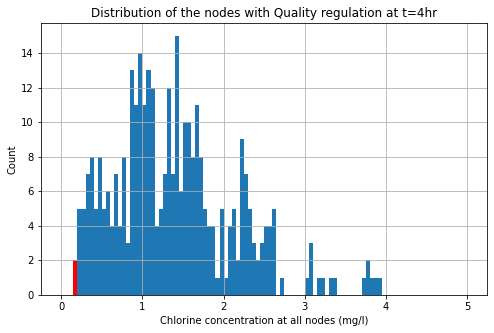

In [117]:
fig = plt.figure(figsize =(8,5))
n, bins, patches = plt.hist(dfk12*1000, 100, histtype ='bar',range=[0,5])
for i in range(4):
    patches[i].set_fc('r')

plt.grid()
plt.title('Distribution of the nodes with Quality regulation at t=4hr')
plt.xlabel('Chlorine concentration at all nodes (mg/l)')
plt.ylabel('Count')

# plt.xlim(0.0001)
# plt.ylim(-0.001,0.008)

# plt.savefig('Hist_wreg.png', dpi=300,bbox_inches='tight')
plt.show()

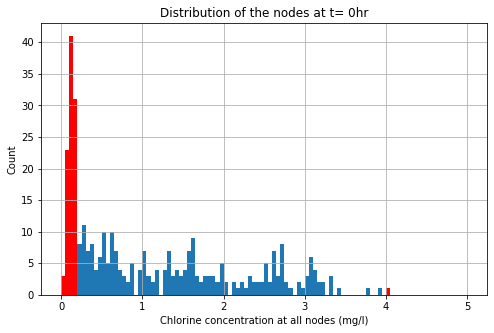

In [118]:
fig = plt.figure(figsize =(8,5))
n, bins, patches = plt.hist(dfk13*1000, 100, histtype ='bar',range=[0,5])
for i in range(4):
    patches[i].set_fc('r')
D = np.linspace(79,99,21)
for i in D:
    patches[int(i)].set_fc('r')
plt.grid()
plt.title('Distribution of the nodes at t= 0hr')
plt.xlabel('Chlorine concentration at all nodes (mg/l)')
plt.ylabel('Count')

# plt.xlim(0.0001)
# plt.ylim(-0.001,0.008)

# plt.savefig('Hist_t0.png', dpi=300,bbox_inches='tight')
plt.show()

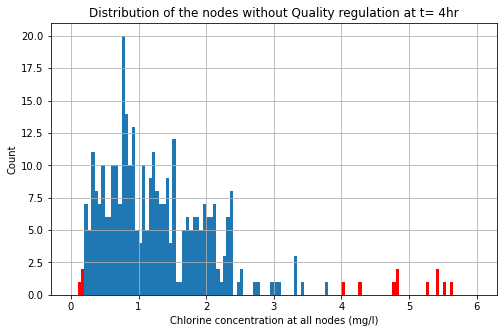

In [119]:
fig = plt.figure(figsize =(8,5))
n, bins, patches = plt.hist(dfk14*1000, 120, histtype ='bar',range=[0,6])
for i in range(4):
    patches[i].set_fc('r')
D = np.linspace(79,119,41)
for i in D:
    patches[int(i)].set_fc('r')
plt.grid()
plt.title('Distribution of the nodes without Quality regulation at t= 4hr')
plt.xlabel('Chlorine concentration at all nodes (mg/l)')
plt.ylabel('Count')

# plt.xlim(0.0001)
# plt.ylim(-0.001,0.008)

# plt.savefig('Hist_woutreg.png', dpi=300,bbox_inches='tight')
plt.show()

In [113]:
np.linspace(79,99,21)

array([79., 80., 81., 82., 83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95., 96., 97., 98., 99.])